Чугунков В.

23-ИИ

Лабортаторная работа 3

Вариант 13

Модель MobileNetV2

### **Классификация 1 картинки**

In [126]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_confusion_matrix

import shutil
import os

In [5]:
model = MobileNetV2(weights = 'imagenet')

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
img = image.load_img("img.jpg", target_size=(224, 224))

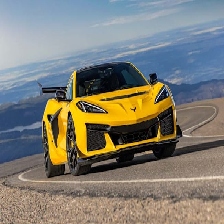

In [9]:
img

In [10]:
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

In [11]:
preds = model.predict(x)
preds.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


(1, 1000)

In [12]:
print('Результаты распознавания: ', decode_predictions(preds, top=3)[0])

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
Результаты распознавания:  [('n04037443', 'racer', np.float32(0.49341804)), ('n02930766', 'cab', np.float32(0.13352947)), ('n04285008', 'sports_car', np.float32(0.06439706))]


### **Импорт изображений**

Кол-во картинок с собаками

In [ ]:
# !ls D:/ML/laba3/PetImages/Cat | wc -l
len(os.listdir("PetImages\\Dog"))

12501

Кол-во картинок с кошками

In [ ]:
len(os.listdir("PetImages\\Cat"))

12501

Кол-во картинок с лошадьми (тренировочный набор)

In [ ]:
len(os.listdir("HH\\train\\horses"))

500

Кол-во картинок с людьми (тренировочный набор)

In [ ]:
len(os.listdir("HH\\train\\humans"))

527

Кол-во картинок с лошадьми (валидационный набор)

In [ ]:
len(os.listdir("HH\\val\\horses"))

128

Кол-во картинок с людьми (валидационный набор)

In [ ]:
len(os.listdir("HH\\val\\humans"))

128

### **Предобработка данных**

In [ ]:
# Необработанный датасет собак и кошек
ks_data_dir = "PetImages"

# CD - папка с предобработанными изображениями собак и кошек
ks_train_dir = "CD\\train"
ks_val_dir   = "CD\\val"
ks_test_dir  = "CD\\test"

# HH - папка с предобработанными изображениями людей и лошадей
hh_train_dir = "HH\\train"
hh_val_dir   = "HH\\val"

test_portion = 0.15
val_portion = 0.15
nb_images_cd = 12500
nb_images_hh = 660

In [128]:
img_width, img_height = 150, 150
input_shape = (img_width, img_height, 3)
epochs = 2
batch_size = 128
nb_train   = 17500
nb_val     = 3750
nb_test    = 3750

Функция для разбиения датасета на выборки

In [129]:
def copy_images(st, ed, src, dst):
  for i in range(st, ed):
    shutil.copy2(os.path.join(src, "Cat/" + str(i) + ".jpg"), dst + "/cats")
    shutil.copy2(os.path.join(src, "Dog/" + str(i) + ".jpg"), dst + "/dogs")

In [130]:
start_val = int(nb_images_cd * (1 - val_portion - test_portion))
start_tst = int(nb_images_cd * (1 - test_portion))

Разбиение кошек и собак на train, val и test

In [38]:
#train
copy_images(0, start_val, ks_data_dir, ks_train_dir)

#val
copy_images(start_val, start_tst, ks_data_dir, ks_val_dir)

#test
copy_images(start_tst, nb_images_cd, ks_data_dir, ks_test_dir)

Обработка лошадей/людей

In [131]:
from pathlib import Path
from PIL import Image

In [132]:
def check_and_clean_dataset(dataset_path, classes):
    """
    Проверка и очистка датасета от поврежденных изображений
    """
    path = Path(dataset_path)
    valid_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

    print("=== ПРОВЕРКА ЦЕЛОСТНОСТИ ИЗОБРАЖЕНИЙ ===")

    for class_name in classes:
        class_path = path / class_name
        if not class_path.exists():
            print(f"Папка {class_path} не существует!")
            continue

        valid_count = 0
        invalid_files = []

        for file_path in class_path.iterdir():
            if file_path.suffix.lower() not in valid_extensions:
                continue

            try:
                with Image.open(file_path) as img:
                    img.verify()  # Проверка целостности файла
                valid_count += 1
            except (IOError, SyntaxError, Exception) as e:
                invalid_files.append(file_path)
                print(f"Поврежденный файл: {file_path} - {e}")
                # Удаляем поврежденный файл
                try:
                    file_path.unlink()
                    print(f"Удален поврежденный файл: {file_path}")
                except Exception as delete_error:
                    print(f"Не удалось удалить {file_path}: {delete_error}")

        print(f"Класс {class_name}: {valid_count} валидных изображений, {len(invalid_files)} поврежденных файлов")

    return True

In [133]:
check_and_clean_dataset(hh_train_dir, ['horses', 'humans'])

=== ПРОВЕРКА ЦЕЛОСТНОСТИ ИЗОБРАЖЕНИЙ ===
Класс horses: 500 валидных изображений, 0 поврежденных файлов
Класс humans: 527 валидных изображений, 0 поврежденных файлов


True

In [42]:
check_and_clean_dataset(hh_val_dir, ['horses', 'humans'])

=== ПРОВЕРКА ЦЕЛОСТНОСТИ ИЗОБРАЖЕНИЙ ===
Класс horses: 128 валидных изображений, 0 поврежденных файлов
Класс humans: 128 валидных изображений, 0 поврежденных файлов


True

In [134]:
datagen = ImageDataGenerator(
    rescale=1./255
)

train_horses_humans = datagen.flow_from_directory(
    hh_train_dir,
    target_size=(img_width, img_height),
    batch_size = batch_size,
    class_mode='binary'
)

val_horses_humans = datagen.flow_from_directory(
    hh_val_dir,
    target_size=(img_width, img_height),
    batch_size = batch_size,
    class_mode='binary'
)

Found 1027 images belonging to 2 classes.
Found 256 images belonging to 2 classes.


Обработка кошек/собак

In [44]:
check_and_clean_dataset(ks_train_dir, ['cats', 'dogs'])

=== ПРОВЕРКА ЦЕЛОСТНОСТИ ИЗОБРАЖЕНИЙ ===
Поврежденный файл: D:\ML\laba3\CD\train\cats\666.jpg - cannot identify image file 'D:\\ML\\laba3\\CD\\train\\cats\\666.jpg'
Удален поврежденный файл: D:\ML\laba3\CD\train\cats\666.jpg
Класс cats: 8749 валидных изображений, 1 поврежденных файлов
Класс dogs: 8750 валидных изображений, 0 поврежденных файлов


True

In [45]:
check_and_clean_dataset(ks_test_dir, ['cats', 'dogs'])

=== ПРОВЕРКА ЦЕЛОСТНОСТИ ИЗОБРАЖЕНИЙ ===
Класс cats: 1875 валидных изображений, 0 поврежденных файлов
Поврежденный файл: D:\ML\laba3\CD\test\dogs\11702.jpg - cannot identify image file 'D:\\ML\\laba3\\CD\\test\\dogs\\11702.jpg'
Удален поврежденный файл: D:\ML\laba3\CD\test\dogs\11702.jpg
Класс dogs: 1874 валидных изображений, 1 поврежденных файлов


True

In [46]:
check_and_clean_dataset(ks_val_dir, ['cats', 'dogs'])

=== ПРОВЕРКА ЦЕЛОСТНОСТИ ИЗОБРАЖЕНИЙ ===
Класс cats: 1875 валидных изображений, 0 поврежденных файлов


C:\Users\Василий\AppData\Roaming\Python\Python313\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Класс dogs: 1875 валидных изображений, 0 поврежденных файлов


True

In [135]:
datagen = ImageDataGenerator(
    rescale=1./255,
)

train_pet = datagen.flow_from_directory(
    ks_train_dir,
    target_size=(img_width, img_height),
    batch_size = batch_size,
    class_mode='binary'
)

test_pet = datagen.flow_from_directory(
    ks_test_dir,
    target_size=(img_width, img_height),
    batch_size = batch_size,
    class_mode='binary'
)

val_pet = datagen.flow_from_directory(
    ks_val_dir,
    target_size=(img_width, img_height),
    batch_size = batch_size,
    class_mode='binary'
)

Found 17499 images belonging to 2 classes.
Found 3749 images belonging to 2 classes.
Found 3750 images belonging to 2 classes.


### **Создание модели**

In [136]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Input, Dropout, Flatten, Activation, Dense, GlobalAveragePooling2D, BatchNormalization

In [137]:
my_model_pets = Sequential()

my_model_pets.add(Input(shape=input_shape))
my_model_pets.add(Conv2D(32, (3, 3), activation='relu'))
my_model_pets.add(MaxPooling2D((2, 2)))

my_model_pets.add(Conv2D(64, (3, 3), activation='relu'))
my_model_pets.add(MaxPooling2D((2, 2)))

my_model_pets.add(Conv2D(128, (3, 3), activation='relu'))
my_model_pets.add(MaxPooling2D((2, 2)))

my_model_pets.add(Conv2D(128, (3, 3), activation='relu'))
my_model_pets.add(MaxPooling2D((2, 2)))

my_model_pets.add(Flatten())
my_model_pets.add(Dropout(0.5))
my_model_pets.add(Dense(512, activation='relu'))
my_model_pets.add(Dropout(0.3))
my_model_pets.add(Dense(1, activation='sigmoid'))

In [138]:
my_model_pets.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [139]:
my_model_pets.compile(loss = 'binary_crossentropy', optimizer= 'adam', metrics = ['accuracy'])

### **Обучение модели (кошки/собаки)**

In [52]:
my_model_pets.fit(train_pet,
                    steps_per_epoch = 17500 // batch_size,
                    epochs = 1,
                    validation_data  = val_pet,
                    validation_steps = nb_val // batch_size)

136/136 ━━━━━━━━━━━━━━━━━━━━ 79s 543ms/step - accuracy: 0.5918 - loss: 0.6664 - val_accuracy: 0.6732 - val_loss: 0.6156


In [53]:
scores = my_model_pets.evaluate(test_pet)

30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 260ms/step - accuracy: 0.6746 - loss: 0.6190


In [54]:
scores

[0.6190158128738403, 0.6745798587799072]

In [55]:
y_pred_proba = my_model_pets.predict(test_pet, verbose = 2)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
y_true = test_pet.classes

30/30 - 7s - 248ms/step


In [56]:
print(classification_report(y_true, y_pred, target_names=list(test_pet.class_indices.keys())))

              precision    recall  f1-score   support

        cats       0.50      0.59      0.54      1875
        dogs       0.49      0.40      0.44      1874

    accuracy                           0.49      3749
   macro avg       0.49      0.49      0.49      3749
weighted avg       0.49      0.49      0.49      3749



(<Figure size 640x480 with 2 Axes>,
 <Axes: xlabel='predicted label', ylabel='true label'>)

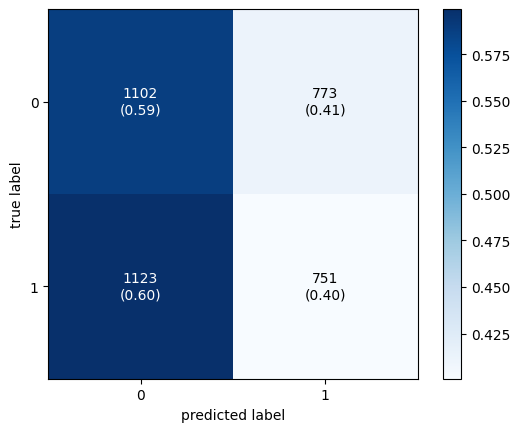

In [57]:
cm = confusion_matrix(y_true, y_pred)
plot_confusion_matrix(conf_mat=cm,show_absolute=True,
                                show_normed=True,
                                colorbar=True)
# Кошки - 0, собаки - 1

In [84]:
# Бинаризация меток для многоклассового случая (хотя у нас 2 класса)
y_test_bin = []
for i in y_true:
    if i == 1:
       y_test_bin.append([0, 1])
    else:
       y_test_bin.append([1, 0])
y_test_bin = np.array(y_test_bin)

# PR-кривые для каждого класса
precision = dict()
recall = dict()
average_precision = dict()

# Для класса 0 (кошки)
precision[0], recall[0], _ = precision_recall_curve(y_test_bin[:, 0], 1 - y_pred_proba)
average_precision[0] = average_precision_score(y_test_bin[:, 0], 1 - y_pred_proba)

# Для класса 1 (собаки)
precision[1], recall[1], _ = precision_recall_curve(y_test_bin[:, 1], y_pred_proba)
average_precision[1] = average_precision_score(y_test_bin[:, 1], y_pred_proba)

# Микро-усреднение
precision["micro"], recall["micro"], _ = precision_recall_curve(
    y_test_bin.ravel(),
    np.column_stack([1 - y_pred_proba, y_pred_proba]).ravel()
)
average_precision["micro"] = average_precision_score(
    y_test_bin,
    np.column_stack([1 - y_pred_proba, y_pred_proba]),
    average="micro"
)

# Макро-усреднение
average_precision["macro"] = average_precision_score(
    y_test_bin,
    np.column_stack([1 - y_pred_proba, y_pred_proba]),
    average="macro"
)

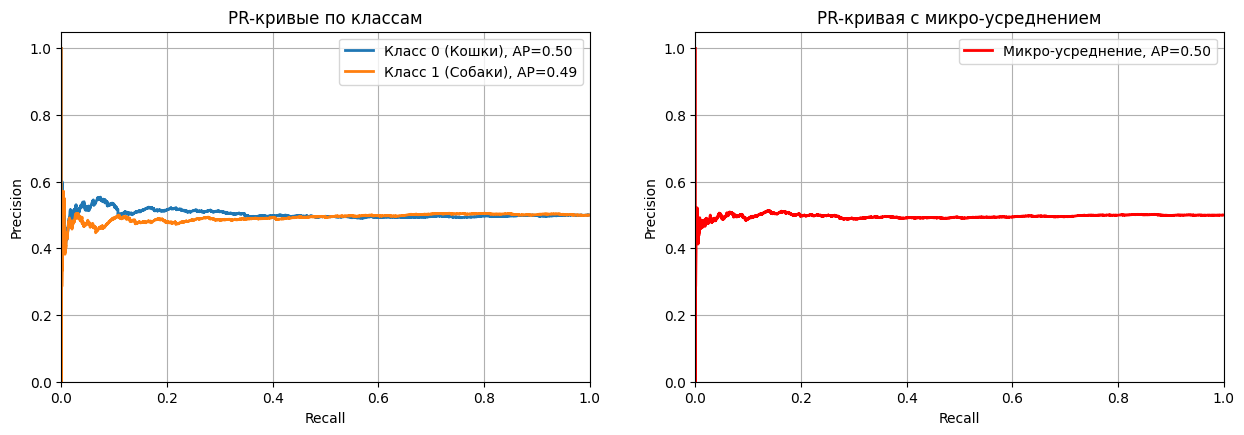

In [85]:
# Построение графиков
plt.figure(figsize=(15, 10))

# PR-кривые для каждого класса
plt.subplot(2, 2, 1)
plt.plot(recall[0], precision[0], lw=2, label=f'Класс 0 (Кошки), AP={average_precision[0]:.2f}')
plt.plot(recall[1], precision[1], lw=2, label=f'Класс 1 (Собаки), AP={average_precision[1]:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('PR-кривые по классам')
plt.legend(loc="best")
plt.grid(True)

# PR-кривая с микро-усреднением
plt.subplot(2, 2, 2)
plt.plot(recall["micro"], precision["micro"], lw=2,
         label=f'Микро-усреднение, AP={average_precision["micro"]:.2f}', color='red')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('PR-кривая с микро-усреднением')
plt.legend(loc="best")
plt.grid(True)

### **Обучение модели (лошади/люди)**

In [140]:
my_model_hh = Sequential()

my_model_hh.add(Input(shape=input_shape))
my_model_hh.add(Conv2D(32, (3, 3), activation='relu'))
my_model_hh.add(MaxPooling2D((2, 2)))

my_model_hh.add(Conv2D(64, (3, 3), activation='relu'))
my_model_hh.add(MaxPooling2D((2, 2)))

my_model_hh.add(Conv2D(128, (3, 3), activation='relu'))
my_model_hh.add(MaxPooling2D((2, 2)))

my_model_hh.add(Conv2D(128, (3, 3), activation='relu'))
my_model_hh.add(MaxPooling2D((2, 2)))

my_model_hh.add(Flatten())
my_model_hh.add(Dropout(0.5))
my_model_hh.add(Dense(512, activation='relu'))
my_model_hh.add(Dropout(0.3))
my_model_hh.add(Dense(1, activation='sigmoid'))

In [141]:
my_model_hh.compile(loss = 'binary_crossentropy', optimizer= 'adam', metrics = ['accuracy'])

In [142]:
my_model_hh.fit(train_horses_humans,
                    steps_per_epoch = 1000 // batch_size,
                    epochs = 4,
                    validation_data  = val_horses_humans,
                    validation_steps = 300 // batch_size)

Epoch 1/4
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.4747 - loss: 0.7431 - val_accuracy: 0.8516 - val_loss: 0.6713
Epoch 2/4
2/7 ━━━━━━━━━━━━━━━━━━━━ 2s 427ms/step - accuracy: 0.7031 - loss: 0.6793

C:\Users\Василий\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step - accuracy: 0.6875 - loss: 0.6789 - val_accuracy: 0.5898 - val_loss: 0.6484
Epoch 3/4
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 922ms/step - accuracy: 0.8158 - loss: 0.5614 - val_accuracy: 0.7930 - val_loss: 0.5896
Epoch 4/4
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.8702 - loss: 0.3296 - val_accuracy: 0.7422 - val_loss: 1.0752


In [89]:
img_hum = image.load_img('human.jpg', target_size=(150, 150))
img_hor = image.load_img('horse.jpg', target_size=(150, 150))

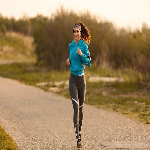

In [90]:
img_hum

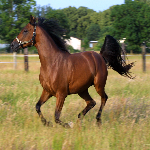

In [91]:
img_hor

In [92]:
x_hum = image.img_to_array(img_hum)
x_hum = np.expand_dims(x_hum, axis=0)
x_hum = preprocess_input(x_hum)
x_hor = image.img_to_array(img_hor)
x_hor = np.expand_dims(x_hor, axis=0)
x_hor = preprocess_input(x_hor)

In [93]:
preds_hor = my_model_hh.predict(x_hor)
preds_hum = my_model_hh.predict(x_hum)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [94]:
preds_hor

array([[1.]], dtype=float32)

In [95]:
preds_hum

array([[1.]], dtype=float32)

In [ ]:
# print('Результаты распознавания лошади: ', decode_predictions(preds_hor, top=3)[0])

ValueError: `decode_predictions` expects a batch of predictions (i.e. a 2D array of shape (samples, 1000)). Received array with shape: (1, 1)

In [ ]:
# print('Результаты распознавания человека: ', decode_predictions(preds_hum, top=3)[0])

ValueError: `decode_predictions` expects a batch of predictions (i.e. a 2D array of shape (samples, 1000)). Received array with shape: (1, 1)

### **Дообучение MobileNetV2 (кошки/собаки)**

In [98]:
mobilenetv2 = MobileNetV2(weights = 'imagenet', include_top = False, input_shape=(150, 150, 3))
mobilenetv2.trainable=False

C:\Users\Василий\AppData\Local\Temp\ipykernel_24044\2305806683.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenetv2 = MobileNetV2(weights = 'imagenet', include_top = False, input_shape=(150, 150, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [99]:
model_mnv2_cd = Sequential([
        mobilenetv2,
        GlobalAveragePooling2D(),
        Dropout(0.2),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(1, activation='sigmoid')  # sigmoid для бинарной классификации
    ])

In [100]:
model_mnv2_cd.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,593 (9.24 MB)

 Trainable params: 164,353 (642.00 KB)

 Non-trainable params: 2,258,240 (8.61 MB)

In [101]:
from tensorflow import keras

In [102]:
opt = keras.optimizers.Adam(learning_rate = 1e-5)

In [103]:
model_mnv2_cd.compile(loss = 'binary_crossentropy', optimizer = opt, metrics=['accuracy'])

In [104]:
scores = model_mnv2_cd.evaluate(test_pet)

30/30 ━━━━━━━━━━━━━━━━━━━━ 19s 499ms/step - accuracy: 0.5967 - loss: 0.7095


In [105]:
scores

[0.709518551826477, 0.5966924428939819]

In [106]:
model_mnv2_cd.fit(train_pet,
                    steps_per_epoch = 17500 // batch_size,
                    epochs = 2,
                    validation_data  = val_pet,
                    validation_steps = nb_val // batch_size)

Epoch 1/2
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.6559 - loss: 0.6575

C:\Users\Василий\AppData\Roaming\Python\Python313\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


136/136 ━━━━━━━━━━━━━━━━━━━━ 81s 525ms/step - accuracy: 0.7336 - loss: 0.5394 - val_accuracy: 0.8974 - val_loss: 0.2940
Epoch 2/2
  1/136 ━━━━━━━━━━━━━━━━━━━━ 51s 382ms/step - accuracy: 0.8672 - loss: 0.3335

C:\Users\Василий\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


136/136 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step - accuracy: 0.8672 - loss: 0.3335 - val_accuracy: 0.8982 - val_loss: 0.2931


In [107]:
y_pred_proba = model_mnv2_cd.predict(test_pet, verbose = 2)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
y_true = test_pet.classes

30/30 - 16s - 540ms/step


In [108]:
print(classification_report(y_true, y_pred, target_names=list(test_pet.class_indices.keys())))

              precision    recall  f1-score   support

        cats       0.50      0.52      0.51      1875
        dogs       0.50      0.47      0.49      1874

    accuracy                           0.50      3749
   macro avg       0.50      0.50      0.50      3749
weighted avg       0.50      0.50      0.50      3749



(<Figure size 640x480 with 2 Axes>,
 <Axes: xlabel='predicted label', ylabel='true label'>)

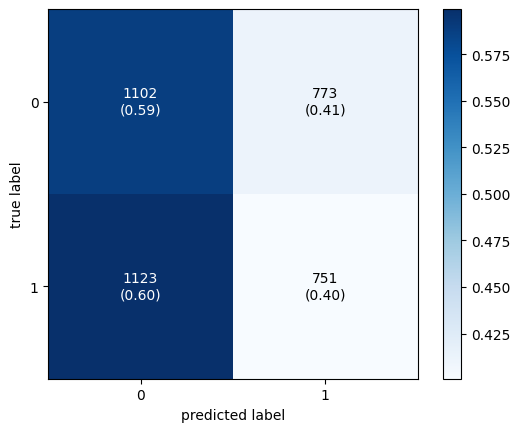

In [109]:
cm_mnv2 = confusion_matrix(y_true, y_pred)
plot_confusion_matrix(conf_mat=cm,show_absolute=True,
                                show_normed=True,
                                colorbar=True)
# Кошки - 0, собаки - 1

In [110]:
# Бинаризация меток для многоклассового случая (хотя у нас 2 класса)
y_test_bin = []
for i in y_true:
    if i == 1:
       y_test_bin.append([0, 1])
    else:
       y_test_bin.append([1, 0])
y_test_bin = np.array(y_test_bin)

# PR-кривые для каждого класса
precision = dict()
recall = dict()
average_precision = dict()

# Для класса 0 (кошки)
precision[0], recall[0], _ = precision_recall_curve(y_test_bin[:, 0], 1 - y_pred_proba)
average_precision[0] = average_precision_score(y_test_bin[:, 0], 1 - y_pred_proba)

# Для класса 1 (собаки)
precision[1], recall[1], _ = precision_recall_curve(y_test_bin[:, 1], y_pred_proba)
average_precision[1] = average_precision_score(y_test_bin[:, 1], y_pred_proba)

# Микро-усреднение
precision["micro"], recall["micro"], _ = precision_recall_curve(
    y_test_bin.ravel(),
    np.column_stack([1 - y_pred_proba, y_pred_proba]).ravel()
)
average_precision["micro"] = average_precision_score(
    y_test_bin,
    np.column_stack([1 - y_pred_proba, y_pred_proba]),
    average="micro"
)

# Макро-усреднение
average_precision["macro"] = average_precision_score(
    y_test_bin,
    np.column_stack([1 - y_pred_proba, y_pred_proba]),
    average="macro"
)

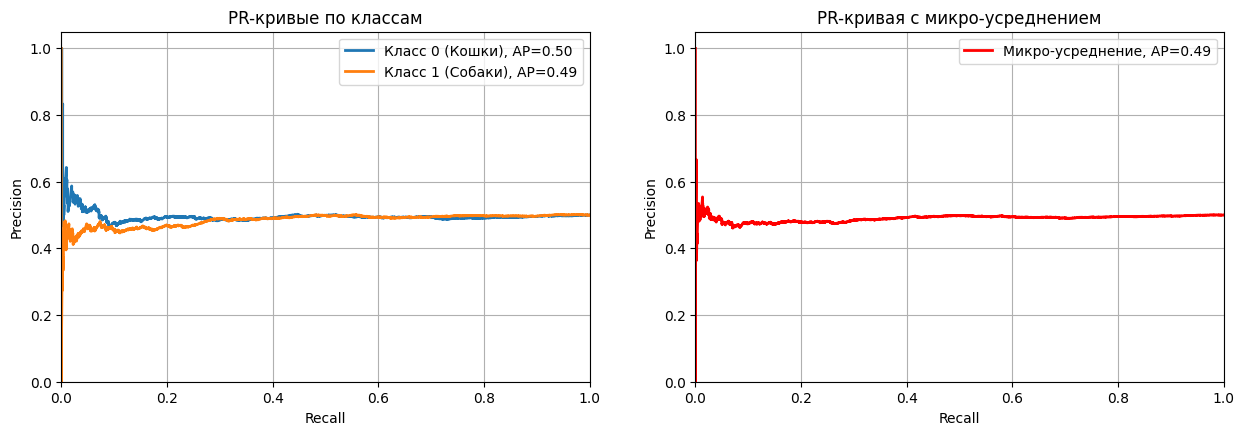

In [111]:
# Построение графиков
plt.figure(figsize=(15, 10))

# PR-кривые для каждого класса
plt.subplot(2, 2, 1)
plt.plot(recall[0], precision[0], lw=2, label=f'Класс 0 (Кошки), AP={average_precision[0]:.2f}')
plt.plot(recall[1], precision[1], lw=2, label=f'Класс 1 (Собаки), AP={average_precision[1]:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('PR-кривые по классам')
plt.legend(loc="best")
plt.grid(True)

# PR-кривая с микро-усреднением
plt.subplot(2, 2, 2)
plt.plot(recall["micro"], precision["micro"], lw=2,
         label=f'Микро-усреднение, AP={average_precision["micro"]:.2f}', color='red')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('PR-кривая с микро-усреднением')
plt.legend(loc="best")
plt.grid(True)

### **Дообучение MobileNetV2 (лошади/люди)**

In [112]:
model_mnv2_hh = Sequential([
        mobilenetv2,
        GlobalAveragePooling2D(),
        Dropout(0.2),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(1, activation='sigmoid')  # sigmoid для бинарной классификации
    ])

In [113]:
model_mnv2_hh.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,593 (9.24 MB)

 Trainable params: 164,353 (642.00 KB)

 Non-trainable params: 2,258,240 (8.61 MB)

In [114]:
opt = keras.optimizers.Adam(learning_rate = 1e-5)

In [115]:
model_mnv2_hh.compile(loss = 'binary_crossentropy', optimizer = opt, metrics=['accuracy'])

In [116]:
model_mnv2_hh.fit(train_horses_humans,
                    steps_per_epoch = 1000 // batch_size,
                    epochs = 1,
                    validation_data  = val_horses_humans,
                    validation_steps = 300 // batch_size)

7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 891ms/step - accuracy: 0.5175 - loss: 0.8372 - val_accuracy: 0.5078 - val_loss: 0.8630


In [117]:
preds_hor = model_mnv2_hh.predict(x_hor)
preds_hum = model_mnv2_hh.predict(x_hum)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 742ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [118]:
preds_hor

array([[0.582335]], dtype=float32)

In [119]:
preds_hum

array([[0.7328553]], dtype=float32)

In [ ]:
# print('Результаты распознавания лошади: ', decode_predictions(preds_hor, top=3)[0])

ValueError: `decode_predictions` expects a batch of predictions (i.e. a 2D array of shape (samples, 1000)). Received array with shape: (1, 1)

In [ ]:
# print('Результаты распознавания человека: ', decode_predictions(preds_hum, top=3)[0])

ValueError: `decode_predictions` expects a batch of predictions (i.e. a 2D array of shape (samples, 1000)). Received array with shape: (1, 1)